In [1]:
!pip install python-docx PyPDF2 pandas scikit-learn nltk matplotlib seaborn wordcloud openpyxl

ERROR: Could not find a version that satisfies the requirement PyPDF2 (from versions: none)
ERROR: No matching distribution found for PyPDF2


In [ ]:
#Imports and constants
import os
import re
from collections import Counter
import pandas as pd
import numpy as np
import docx
from PyPDF2 import PdfReader
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Path to folder with your uploaded files (this notebook assumes uploads were saved to /mnt/data/)
from google.colab import drive
drive.mount('/content/drive')
DATA_FOLDER = "/content/drive/MyDrive/Resumes"
OUTPUT_FOLDER = "./output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

STOPWORDS = set(stopwords.words('english'))

In [4]:
#File reading utilities
# docx reader
def extract_text_docx(path):
    try:
        doc = docx.Document(path)
        return "\n".join([p.text for p in doc.paragraphs])
    except Exception as e:
        return ""

# pdf reader
def extract_text_pdf(path):
    try:
        reader = PdfReader(path)
        text = ""
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
        return text
    except Exception as e:
        return ""

# generic wrapper
def extract_text_from_file(path):
    low = path.lower()
    if low.endswith(".docx"):
        return extract_text_docx(path)
    if low.endswith(".pdf"):
        return extract_text_pdf(path)
    # .doc older binary files often not reliably readable - skip or convert externally
    if low.endswith(".doc"):
        # best-effort: try docx if file actually docx with wrong extension; else skip
        try:
            return extract_text_docx(path)
        except:
            return ""
    # otherwise return empty
    return ""


In [5]:
#Build dataset by iterating files in DATA_FOLDER
from google.colab import drive
 # Correcting the path to the data folder

rows = []
files = sorted([f for f in os.listdir(DATA_FOLDER) if f.lower().endswith(('.docx', '.doc', '.pdf'))])

print(f"Found {len(files)} candidate files in {DATA_FOLDER} (showing first 20):")
print(files[:20])

for fname in files:
    fpath = os.path.join(DATA_FOLDER, fname)
    text = extract_text_from_file(fpath)
    if not text or len(text.strip()) < 20:
        # skip very small / empty extractions
        print("Skipped (empty or unreadable):", fname)
        continue
    rows.append({"filename": fname, 'C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx': fpath, "text": text})

df = pd.DataFrame(rows)
print("Extracted text from files:", df.shape)
df.head(3)


Found 79 candidate files in /content/drive/MyDrive/Resumes (showing first 20):
['Anil kumar.docx', 'AradhanaTripathi[4_0].docx', 'Buddha Vamsi.docx', 'ChinnaSubbarayuduM_Hexaware.docx', 'Gopi Krishna_Hexaware.docx', 'Hari Krishna M_Hexaware.doc', 'Harikrishna Akula_Hexaware.doc', 'Hima Mendu_Hexaware.doc', 'Himaja G_(Hexaware).docx', 'Internship_Ravali_Musquare Technologies (1).docx', 'Internship_Susovan Bag_Musquare Technologies.docx', 'J. Sumanth Royal_Hexaware.doc', 'Jyotiverma_Heaware.docx', 'Madeeswar A_Hexaware.doc', 'MooraboyinaGuravaiah_Hexaware.docx', 'Naresh Babu Cherukuri_Hexaware.doc', 'Nazeer Basha.doc', 'Neeraj Mishra.docx', 'P V Sai Krishna_ Hexaware.docx', 'PSyamKumar[2_3].docx']
Skipped (empty or unreadable): Hari Krishna M_Hexaware.doc
Skipped (empty or unreadable): Harikrishna Akula_Hexaware.doc
Skipped (empty or unreadable): Hima Mendu_Hexaware.doc
Skipped (empty or unreadable): J. Sumanth Royal_Hexaware.doc
Skipped (empty or unreadable): Madeeswar A_Hexaware.doc
Sk

,filename,C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx,text
0,Anil kumar.docx,/content/drive/MyDrive/Resumes/Anil kumar.docx,ANIL KUMAR MADDUKURI \t\t\nSQL & MSBI Develop...
1,AradhanaTripathi[4_0].docx,/content/drive/MyDrive/Resumes/AradhanaTripath...,\nAradhana Tripathi\n\nCurrent Location: Gachi...
2,Buddha Vamsi.docx,/content/drive/MyDrive/Resumes/Buddha Vamsi.docx,BUDDHA VAMSI ...


In [6]:
#Build dataset by iterating files in DATA_FOLDER
rows = []
files = sorted([f for f in os.listdir(DATA_FOLDER) if f.lower().endswith(('.docx', '.doc', '.pdf'))])

print(f"Found {len(files)} candidate files in {DATA_FOLDER} (showing first 20):")
print(files[:20])

for fname in files:
    fpath = os.path.join(DATA_FOLDER, fname)
    text = extract_text_from_file(fpath)
    if not text or len(text.strip()) < 20:
        # skip very small / empty extractions
        print("Skipped (empty or unreadable):", fname)
        continue
    rows.append({"filename": fname, "C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx": fpath, "text": text})

df = pd.DataFrame(rows)
print("Extracted text from files:", df.shape)
df.head(3)


Found 79 candidate files in /content/drive/MyDrive/Resumes (showing first 20):
['Anil kumar.docx', 'AradhanaTripathi[4_0].docx', 'Buddha Vamsi.docx', 'ChinnaSubbarayuduM_Hexaware.docx', 'Gopi Krishna_Hexaware.docx', 'Hari Krishna M_Hexaware.doc', 'Harikrishna Akula_Hexaware.doc', 'Hima Mendu_Hexaware.doc', 'Himaja G_(Hexaware).docx', 'Internship_Ravali_Musquare Technologies (1).docx', 'Internship_Susovan Bag_Musquare Technologies.docx', 'J. Sumanth Royal_Hexaware.doc', 'Jyotiverma_Heaware.docx', 'Madeeswar A_Hexaware.doc', 'MooraboyinaGuravaiah_Hexaware.docx', 'Naresh Babu Cherukuri_Hexaware.doc', 'Nazeer Basha.doc', 'Neeraj Mishra.docx', 'P V Sai Krishna_ Hexaware.docx', 'PSyamKumar[2_3].docx']
Skipped (empty or unreadable): Hari Krishna M_Hexaware.doc
Skipped (empty or unreadable): Harikrishna Akula_Hexaware.doc
Skipped (empty or unreadable): Hima Mendu_Hexaware.doc
Skipped (empty or unreadable): J. Sumanth Royal_Hexaware.doc
Skipped (empty or unreadable): Madeeswar A_Hexaware.doc
Sk

,filename,C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx,text
0,Anil kumar.docx,/content/drive/MyDrive/Resumes/Anil kumar.docx,ANIL KUMAR MADDUKURI \t\t\nSQL & MSBI Develop...
1,AradhanaTripathi[4_0].docx,/content/drive/MyDrive/Resumes/AradhanaTripath...,\nAradhana Tripathi\n\nCurrent Location: Gachi...
2,Buddha Vamsi.docx,/content/drive/MyDrive/Resumes/Buddha Vamsi.docx,BUDDHA VAMSI ...


In [7]:
#Basic cleaning helpers and auto-label function
def basic_clean(text):
    text = str(text)
    # normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def text_to_lower_onlyalpha(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def assign_label_auto(text):
    t = text.lower()
    # priority order - tune keywords as necessary
    if any(k in t for k in ["react", "redux", "frontend", "javascript", "mui", "reactjs"]):
        return "React Developer"
    if any(k in t for k in ["ssis", "ssrs", "t-sql", "msbi", "etl", "power bi", "powerbi", "sql developer", "pl/sql", "oracle sql"]):
        return "SQL Developer"
    if any(k in t for k in ["workday", "eib", "studio", "core connector", "picof", "peci", "workday studio"]):
        return "Workday Consultant"
    if any(k in t for k in ["peoplesoft", "peoplecode", "application engine", "ps query", "fscm", "hcm", "component interface", "app engine"]):
        return "PeopleSoft Consultant"
    if any(k in t for k in ["test cases", "manual testing", "stlc", "sdlc", "qa", "tester"]):
        return "Manual Tester"
    return "Other"


In [8]:
# Create dataframe columns: raw, cleaned, tokenized, label
df['text_raw'] = df['text'].apply(basic_clean)
df['text_alpha'] = df['text_raw'].apply(text_to_lower_onlyalpha)
df['word_count'] = df['text_alpha'].apply(lambda x: len(x.split()))
df['label_auto'] = df['text_raw'].apply(assign_label_auto)
df['extension'] = df['filename'].apply(lambda x: x.split(".")[-1].lower())

# show summary
df[['filename','extension','word_count','label_auto']].sort_values('word_count', ascending=False).head(10)


,filename,extension,word_count,label_auto
13,PeopleSoft DBA_Vivekanand Sayana.docx,docx,1962,SQL Developer
22,RahulM_Hexaware.docx,docx,1250,Workday Consultant
47,SSKumar_Hexaware.docx,docx,1030,Workday Consultant
17,Peoplesoft Admin_Varkala Vikas.docx,docx,949,SQL Developer
25,RameshNataru[3_4].docx,docx,917,SQL Developer
14,Peoplesoft Admin_AnubhavSingh.docx,docx,901,SQL Developer
9,MooraboyinaGuravaiah_Hexaware.docx,docx,889,Workday Consultant
48,Srikanth-Hexaware.docx,docx,853,Workday Consultant
3,ChinnaSubbarayuduM_Hexaware.docx,docx,816,SQL Developer
36,React JS Developer_KotaniDurgaprasad[3_1] (1)-...,docx,794,React Developer


In [9]:
#Save initial dataset CSV (backup)
df.to_csv(os.path.join(OUTPUT_FOLDER, "raw_resume_dataset.csv"), index=False)
print("Saved raw dataset to:", os.path.join(OUTPUT_FOLDER, "raw_resume_dataset.csv"))


Saved raw dataset to: ./output/raw_resume_dataset.csv


In [10]:
# EDA - overview and missing checks
print("Total resumes:", len(df))
print("\nCounts by auto label:\n", df['label_auto'].value_counts())

# missing values
print("\nMissing counts per column:\n", df.isnull().sum())


Total resumes: 53

Counts by auto label:
 label_auto
SQL Developer            20
React Developer          20
Workday Consultant       11
PeopleSoft Consultant     2
Name: count, dtype: int64

Missing counts per column:
 filename                                                           0
C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx    0
text                                                               0
text_raw                                                           0
text_alpha                                                         0
word_count                                                         0
label_auto                                                         0
extension                                                          0
dtype: int64


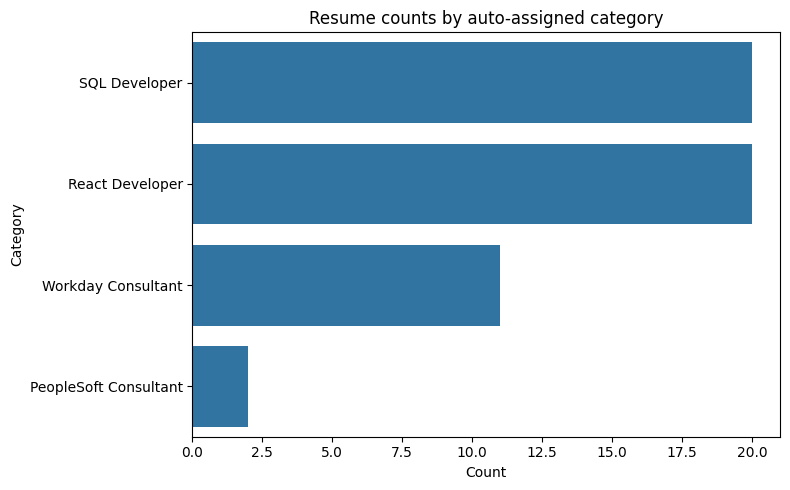

In [11]:
#Visual: category distribution
plt.figure(figsize=(8,5))
sns.countplot(y='label_auto', data=df, order=df['label_auto'].value_counts().index)
plt.title("Resume counts by auto-assigned category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


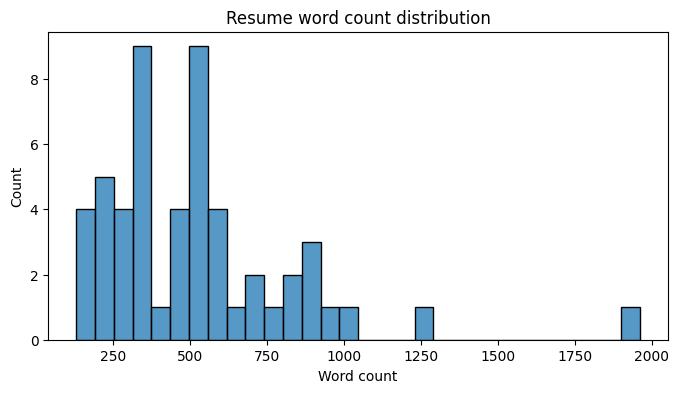

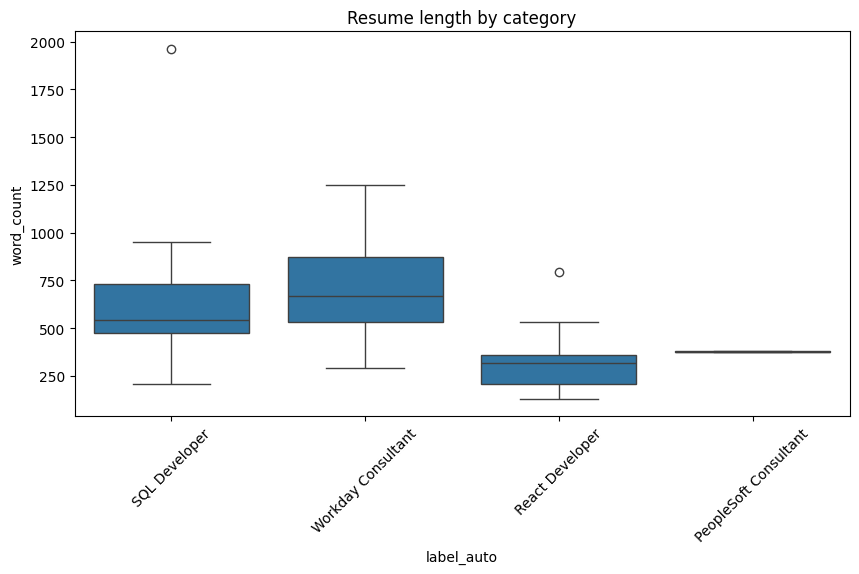

In [12]:
#Resume length distribution
plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=30, kde=False)
plt.title("Resume word count distribution")
plt.xlabel("Word count")
plt.show()

# boxplot by category
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='label_auto', y='word_count')
plt.xticks(rotation=45)
plt.title("Resume length by category")
plt.show()


In [13]:
# Top words overall and per category
def top_n_words(text_series, n=30):
    all_words = " ".join(text_series).split()
    counter = Counter(all_words)
    return counter.most_common(n)

print("Top 20 words overall:")
print(top_n_words(df['text_alpha'], 20))

# per category top 15
for cat in df['label_auto'].unique():
    text = " ".join(df[df['label_auto']==cat]['text_alpha'])
    print(f"\nTop words for {cat}:")
    print(top_n_words([text], 15))


Top 20 words overall:
[('and', 1399), ('the', 766), ('in', 707), ('to', 630), ('of', 508), ('on', 375), ('for', 360), ('experience', 313), ('using', 247), ('with', 227), ('as', 221), ('workday', 194), ('application', 187), ('a', 180), ('sql', 178), ('project', 177), ('from', 175), ('server', 169), ('data', 167), ('reports', 164)]

Top words for SQL Developer:
[('and', 714), ('in', 337), ('the', 337), ('of', 273), ('to', 258), ('sql', 173), ('server', 166), ('for', 159), ('on', 158), ('experience', 157), ('peoplesoft', 139), ('application', 111), ('using', 107), ('data', 103), ('as', 84)]

Top words for Workday Consultant:
[('and', 399), ('the', 208), ('in', 205), ('to', 205), ('workday', 174), ('on', 144), ('for', 109), ('of', 108), ('business', 96), ('reports', 86), ('as', 84), ('with', 80), ('experience', 80), ('integrations', 80), ('using', 68)]

Top words for React Developer:
[('and', 254), ('the', 185), ('in', 160), ('to', 131), ('of', 123), ('react', 119), ('js', 97), ('for', 82)

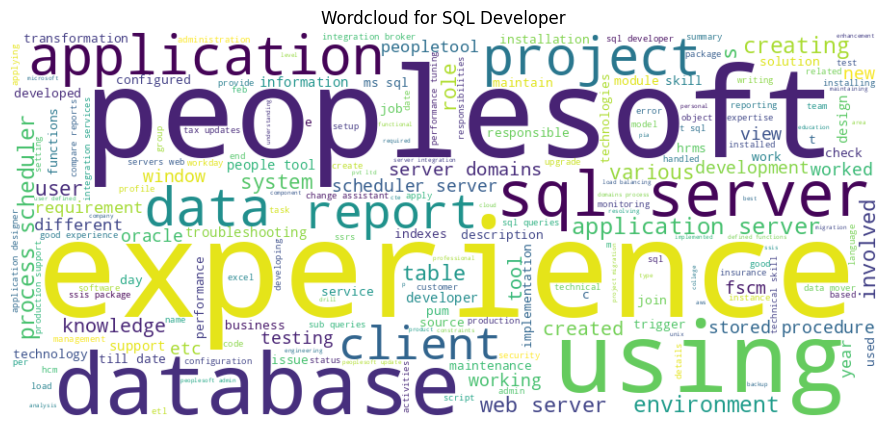

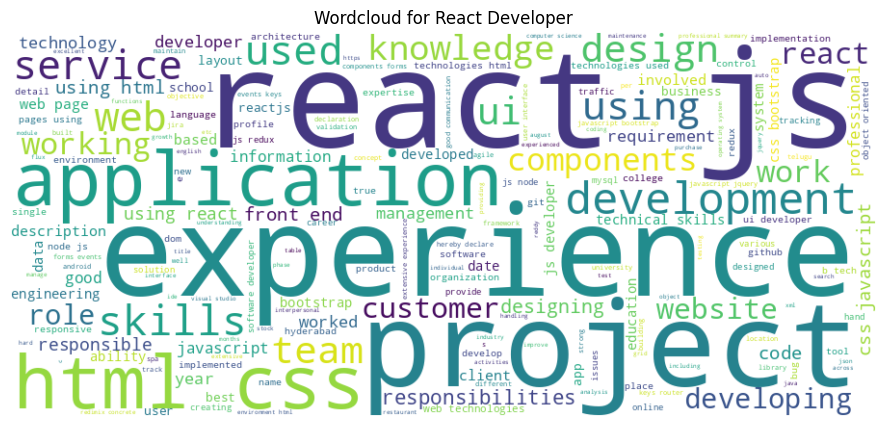

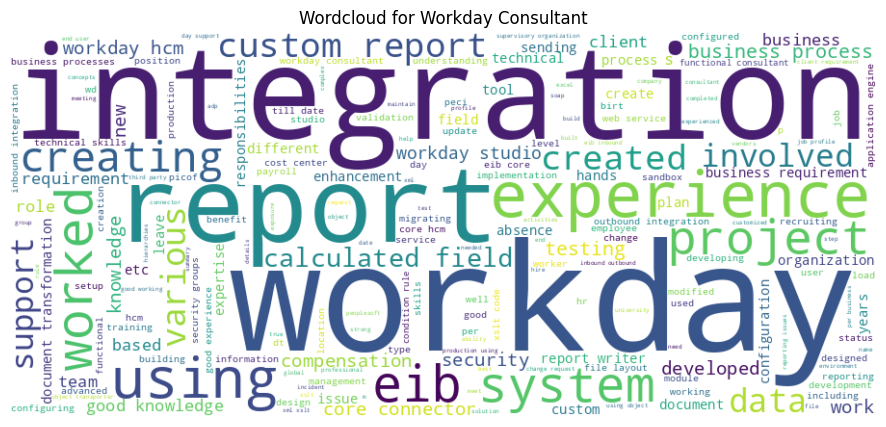

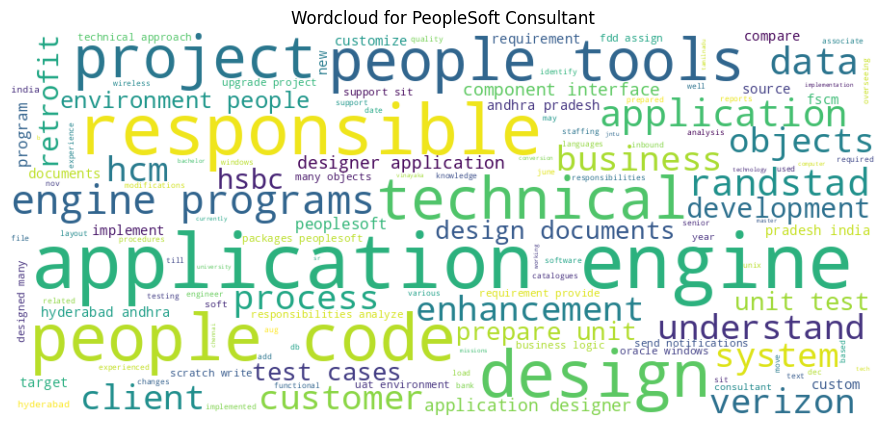

In [14]:
# Wordclouds per category (visual)
for cat in df['label_auto'].value_counts().index:
    text = " ".join(df[df['label_auto']==cat]['text_alpha'])
    if len(text.strip())==0:
        continue
    wc = WordCloud(width=900, height=400, background_color='white').generate(text)
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Wordcloud for {cat}")
    plt.show()


In [15]:
#Keyword counts useful for debugging labels
keywords = ["react","redux","javascript","sql","ssis","ssrs","peoplesoft","workday","eib","fscm","hcm","app engine","peoplecode"]
for kw in keywords:
    df[f"kw_{kw}"] = df['text_alpha'].apply(lambda x: x.split().count(kw))
kw_counts = {kw: int(df[f"kw_{kw}"].sum()) for kw in keywords}
print("Keyword totals:", kw_counts)


Keyword totals: {'react': 119, 'redux': 22, 'javascript': 47, 'sql': 178, 'ssis': 28, 'ssrs': 14, 'peoplesoft': 156, 'workday': 194, 'eib': 62, 'fscm': 36, 'hcm': 78, 'app engine': 0, 'peoplecode': 2}


In [16]:
#Duplicate detection (exact cleaned text duplicates)
dups = df[df.duplicated('text_alpha', keep=False)].sort_values('label_auto')
print("Number of duplicate text entries:", len(dups))
if len(dups)>0:
    display(dups[['filename','label_auto','word_count']].head(20))


Number of duplicate text entries: 4


,filename,label_auto,word_count
27,React Dev_Krishna Kanth.docx,React Developer,530
28,React Dev_Krishna Kanth_Musquare Technologies....,React Developer,530
38,Reactjs Developer_M Lokesh Babu_Musquare Techn...,React Developer,305
39,Reactjs Developer_M Lokesh.docx,React Developer,305


In [17]:
#Manual label corrections (OPTIONAL)

print(df['label_auto'].value_counts())


label_auto
SQL Developer            20
React Developer          20
Workday Consultant       11
PeopleSoft Consultant     2
Name: count, dtype: int64


In [18]:
df['text_alpha']

,text_alpha
0,anil kumar maddukuri sql msbi developer summar...
1,aradhana tripathi current location gachibowli ...
2,buddha vamsi career objective have years of it...
3,chinna subbarayudu m dob th march nationality ...
4,name gopi krishna reddy professional summery w...
5,g himaja career objective to work towards achi...
6,name ravali p curriculum vitae specialization ...
7,susovan bag seeking a challenging position in ...
8,jyoti verma years of experience in workday as ...
9,mooraboyina guravaiah workday integration spec...


In [19]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()
df['label_auto']=LE.fit_transform(df['label_auto'])


In [20]:
# splitting the Indepedent and Depedent Variable
from sklearn.model_selection import train_test_split
X=df['text_alpha']
Y=df['label_auto']

x_train,x_test,y_train,y_test=train_test_split(X,Y, test_size=0.2,random_state=42)

x_train


,text_alpha
8,jyoti verma years of experience in workday as ...
26,ramesh a workday hcm consultant professional s...
6,name ravali p curriculum vitae specialization ...
34,sri geethika prestige road number bandari layo...
4,name gopi krishna reddy professional summery w...
37,venkatalakshmi pedireddy software developer ex...
24,resume ramalakshmi k career objective professi...
44,shaik abdul sharuk years experience in wipro c...
33,pragnya pattnaik expertise having around years...
49,vinay kumar v workday functional consultant ex...


In [21]:
#TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf = tfidf.transform(x_test)

# quick sanity
print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (42, 5000)


In [22]:
X_train_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Modeling Step

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [ ]:
results = []

# 1) Multinomial Naive Bayes (fast baseline)
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)
y_pred = nb.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print("=== MultinomialNB ===")
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))
results.append(("MultinomialNB", acc))

In [ ]:
# 2) Logistic Regression with small GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
lr = LogisticRegression(max_iter=2000, solver='saga', multi_class='auto')
param_grid = {'C':[0.01,0.1,1,10], 'penalty':['l2']}  # L1 can be slow; adjust if desired
grid_lr = GridSearchCV(lr, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_lr.fit(X_train_tfidf, y_train)
best_lr = grid_lr.best_estimator_
y_pred = best_lr.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print("\n=== LogisticRegression (GridSearchCV best) ===")
print("Best params:", grid_lr.best_params_)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))
results.append(("LogisticRegression", acc))

In [ ]:
# 3) LinearSVC with GridSearchCV
from sklearn.svm import LinearSVC
svc = LinearSVC(max_iter=5000)
param_grid = {'C':[0.01,0.1,1,10]}
grid_svc = GridSearchCV(svc, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_svc.fit(X_train_tfidf, y_train)
best_svc = grid_svc.best_estimator_
y_pred = best_svc.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print("\n=== LinearSVC (GridSearchCV best) ===")
print("Best params:", grid_svc.best_params_)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))
results.append(("LinearSVC", acc))

In [ ]:
# 4) LightGBM (tree boosting)
# If not installed: pip install lightgbm
try:
    import lightgbm as lgb
    lgb_clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31, n_jobs=-1)
    lgb_clf.fit(X_train_tfidf, y_train)
    y_pred = lgb_clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print("\n=== LightGBM ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    results.append(("LightGBM", acc))
except Exception as e:
    print("\nLightGBM not available or failed to run:", e)

In [ ]:
# 5) Stacking classifier (meta-learner)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.naive_bayes import MultinomialNB

estimators = [
    ('lr', LogisticRegression(C=1, max_iter=2000, solver='saga')),
    ('svc', LinearSVC(C=1.0, max_iter=5000)),
    ('nb', MultinomialNB(alpha=1.0))
]
stack = StackingClassifier(estimators=estimators, final_estimator=RidgeClassifier(), n_jobs=-1)
stack.fit(X_train_tfidf, y_train)
y_pred = stack.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print("\n=== StackingClassifier ===")
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))
results.append(("StackingClassifier", acc))

In [ ]:
# Summary table of results
results_df = pd.DataFrame(results, columns=['model','accuracy']).sort_values('accuracy', ascending=False).reset_index(drop=True)
print("\n=== Results summary ===")
print(results_df)